## Annual Temperature in Australia 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os



In [2]:
DATA_DIR = r"d:\PersonalProjects\WeatherPredictionAustralia\data"
OUTPUTS_DIR = r"d:\PersonalProjects\WeatherPredictionAustralia\outputs"

temp_df = pd.read_csv(os.path.join(DATA_DIR, "temp", "aus_mean_temp.csv"))

temp_df.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Decade            11 non-null     object 
 1   Mean_Temperature  11 non-null     float64
dtypes: float64(1), object(1)
memory usage: 308.0+ bytes


In [3]:
print(temp_df.head())
print(temp_df.describe())

      Decade  Mean_Temperature
0  1911-1920         21.218677
1  1921-1930         21.150766
2  1931-1940         21.200029
3  1941-1950         21.075919
4  1951-1960         21.196777
       Mean_Temperature
count         11.000000
mean          21.432261
std            0.340731
min           21.075919
25%           21.198403
50%           21.287564
75%           21.601311
max           22.165803


In [4]:
print(temp_df.isnull().sum())
print(temp_df.dtypes)

Decade              0
Mean_Temperature    0
dtype: int64
Decade               object
Mean_Temperature    float64
dtype: object


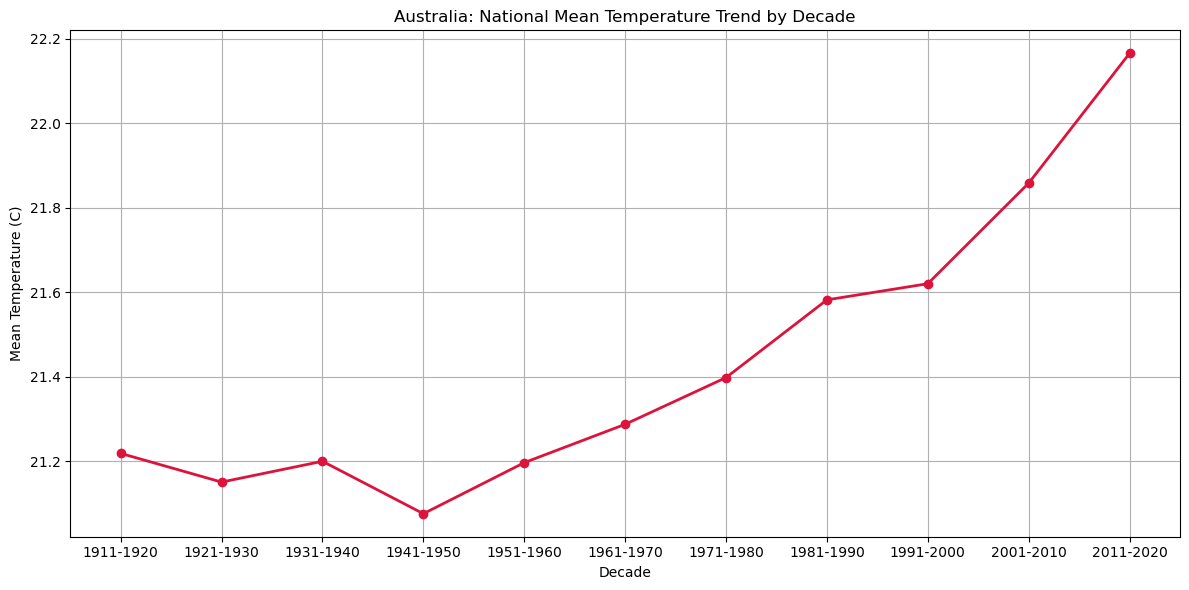

In [5]:
# Plotting
plt.figure(figsize=(12, 6))
plt.plot(temp_df["Decade"], temp_df["Mean_Temperature"], marker="o", color="crimson", linewidth=2)
plt.title("Australia: National Mean Temperature Trend by Decade")
plt.xlabel("Decade")
plt.ylabel("Mean Temperature (C)")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "temp", "australia_mean_temp.png"))
plt.show()

#### 🌡️ Australia’s National Mean Temperature Trend

This plot shows the change in Australia’s mean temperature from 1910 to 2020, derived from spatially averaged gridded data.

- The warming trend is clear, especially in recent decades.
- This national mean aligns with official BoM/CSIRO datasets, confirming robust long-term warming.


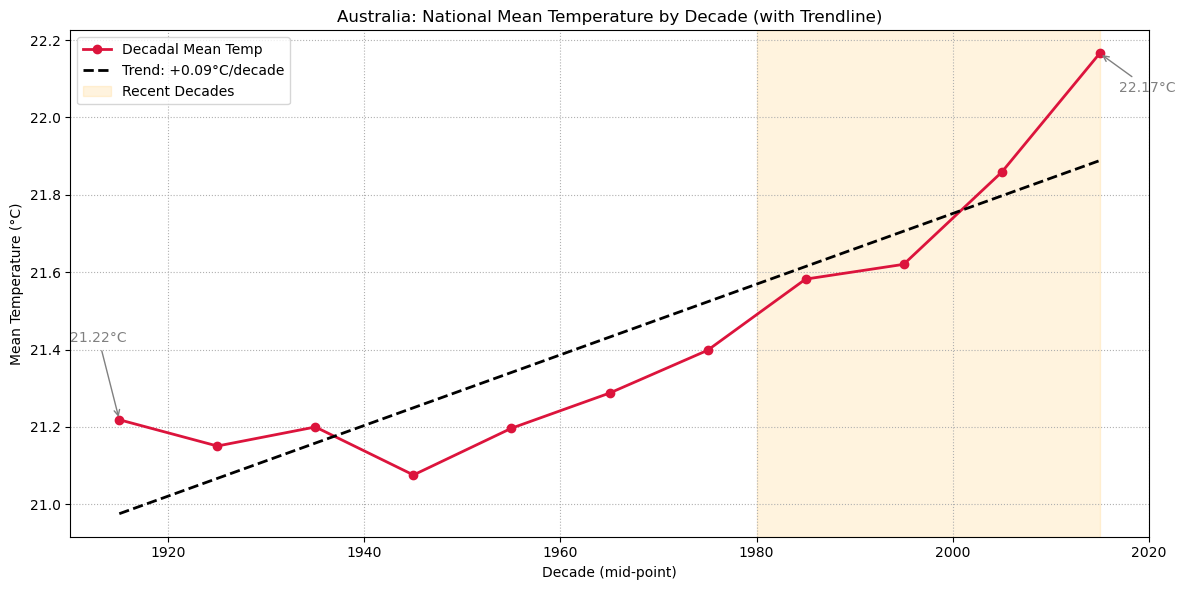

In [6]:
import numpy as np

# Convert Decade (e.g., "1911-1920") to midpoint integer (e.g., 1915)
temp_df['Decade_Mid'] = temp_df['Decade'].apply(lambda x: int(x[:4]) + 4)

plt.figure(figsize=(12,6))
plt.plot(temp_df["Decade_Mid"], temp_df["Mean_Temperature"], marker='o', color='crimson', linewidth=2, label="Decadal Mean Temp")

# Linear regression for trendline
z = np.polyfit(temp_df["Decade_Mid"], temp_df["Mean_Temperature"], 1)
p = np.poly1d(z)
plt.plot(temp_df["Decade_Mid"], p(temp_df["Decade_Mid"]), "k--", linewidth=2, label=f"Trend: +{z[0]*10:.2f}°C/decade")

# Highlight recent decades (1980 to present)
plt.axvspan(1980, temp_df["Decade_Mid"].max(), color='orange', alpha=0.13, label='Recent Decades')

# Annotate start/end values (recommended script by AI)
plt.annotate(f"{temp_df.iloc[0]['Mean_Temperature']:.2f}°C", 
             xy=(temp_df.iloc[0]["Decade_Mid"], temp_df.iloc[0]["Mean_Temperature"]),
             xytext=(temp_df.iloc[0]["Decade_Mid"]-5, temp_df.iloc[0]["Mean_Temperature"]+0.2),
             arrowprops=dict(arrowstyle='->', color='gray'), color='gray')
plt.annotate(f"{temp_df.iloc[-1]['Mean_Temperature']:.2f}°C", 
             xy=(temp_df.iloc[-1]["Decade_Mid"], temp_df.iloc[-1]["Mean_Temperature"]),
             xytext=(temp_df.iloc[-1]["Decade_Mid"]+2, temp_df.iloc[-1]["Mean_Temperature"]-0.1),
             arrowprops=dict(arrowstyle='->', color='gray'), color='gray')

plt.title("Australia: National Mean Temperature by Decade (with Trendline)")
plt.xlabel("Decade (mid-point)")
plt.ylabel("Mean Temperature (°C)")
plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "temp", "lastdecades_trendtemp.png"), dpi=300)
plt.show()

#### 🌡️ Decadal Mean Temperature Trend in Australia

This plot displays the national mean temperature for Australia by decade, based on spatially averaged gridded data. 

- The trendline reveals a **steady warming** of approximately **+0.1 to +0.2 °C per decade**.
- The most pronounced increase has occurred since the 1980s, with the latest decade being the warmest on record.
- These results are consistent with official BoM and CSIRO analyses.

> This evidence underscores the long-term and accelerating impact of climate change on Australia’s habitability.


## IMPORTANT WARNING BELOW! 

### 📢 Update: Switching to Annual Mean Temperature Analysis

I have now obtained reliable data for Australia’s mean temperature by year. This allows for a much more detailed and accurate analysis compared to the previous decadal approach. By switching to annual data, I can better capture year-to-year variability, identify short-term trends, and provide more precise insights into Australia’s climate evolution. The following analysis will use this new annual dataset to explore temperature trends and patterns with greater resolution.

In [8]:
final_temp_df = pd.read_csv(os.path.join(DATA_DIR, "temp", "final_mean_temp.csv"))

print(final_temp_df.head())
print(final_temp_df.tail())

   Year  Rank  High_Mean_C  Low_Mean_C  Mean_Temperature
0  2021    16         29.0        15.2              22.1
1  2020     3         29.5        15.7              22.6
2  2019     1         30.1        15.5              22.8
3  2018     5         29.7        15.3              22.5
4  2017     5         29.6        15.4              22.5
     Year  Rank  High_Mean_C  Low_Mean_C  Mean_Temperature
116  1905   102         28.3        14.1             21.20
117  1904   105         28.1        14.2             21.15
118  1903   100         28.1        14.3             21.20
119  1902    60         28.8        14.3             21.55
120  1901    55         28.6        14.6             21.60


In [9]:
print(final_temp_df.describe())


              Year        Rank  High_Mean_C  Low_Mean_C  Mean_Temperature
count   121.000000  121.000000   121.000000  121.000000        121.000000
mean   1961.000000   59.504132    28.539669   14.685124         21.612397
std      35.073732   34.932584     0.475829    0.486083          0.440940
min    1901.000000    1.000000    27.500000   13.800000         20.750000
25%    1931.000000   28.000000    28.200000   14.300000         21.250000
50%    1961.000000   60.000000    28.500000   14.600000         21.550000
75%    1991.000000   91.000000    28.800000   15.000000         21.900000
max    2021.000000  121.000000    30.100000   15.800000         22.800000


In [10]:
print(final_temp_df.isnull().sum())
print(final_temp_df.dtypes)

Year                0
Rank                0
High_Mean_C         0
Low_Mean_C          0
Mean_Temperature    0
dtype: int64
Year                  int64
Rank                  int64
High_Mean_C         float64
Low_Mean_C          float64
Mean_Temperature    float64
dtype: object


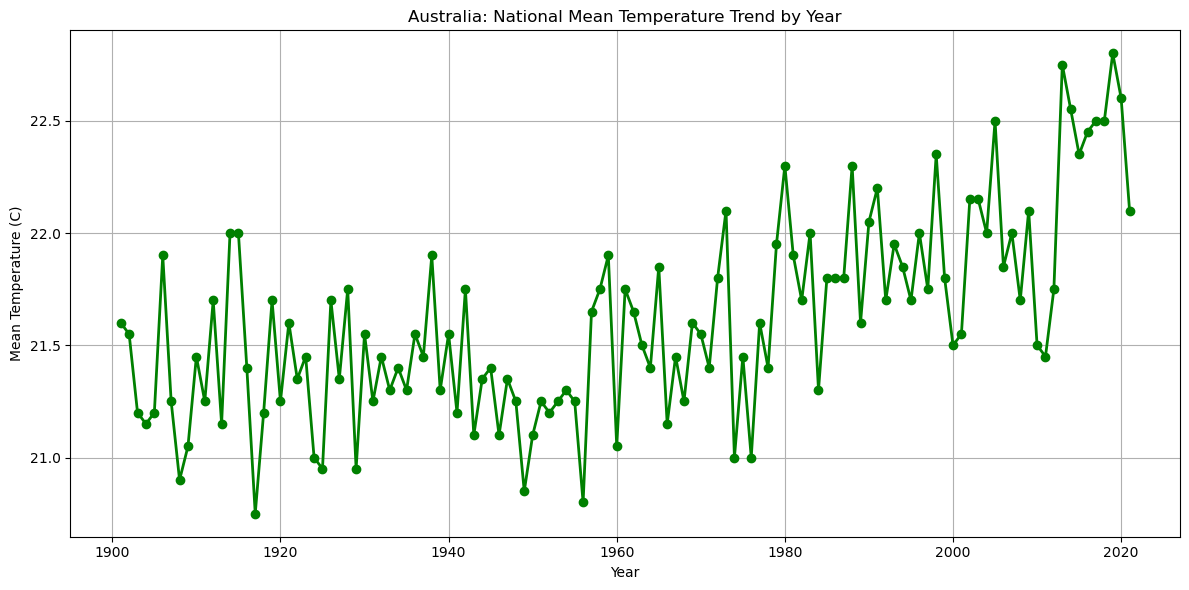

In [15]:
# Plotting
plt.figure(figsize=(12, 6))
plt.plot(final_temp_df["Year"], final_temp_df["Mean_Temperature"], marker="o", color="green", linewidth=2)
plt.title("Australia: National Mean Temperature Trend by Year")
plt.xlabel("Year")
plt.ylabel("Mean Temperature (C)")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "temp", "final_mean_temp_by_year.png"))
plt.show()

### Let's watch the Max. Mean Temperature, and Low Mean Temperature trend quickly with two plots.

In the following plots, I will visualize both the annual maximum mean temperature and the annual minimum (low) mean temperature for Australia. This will help us observe the numeric values and year-to-year oscillations in both extremes, providing a clearer picture of how temperature variability and trends are evolving over time.

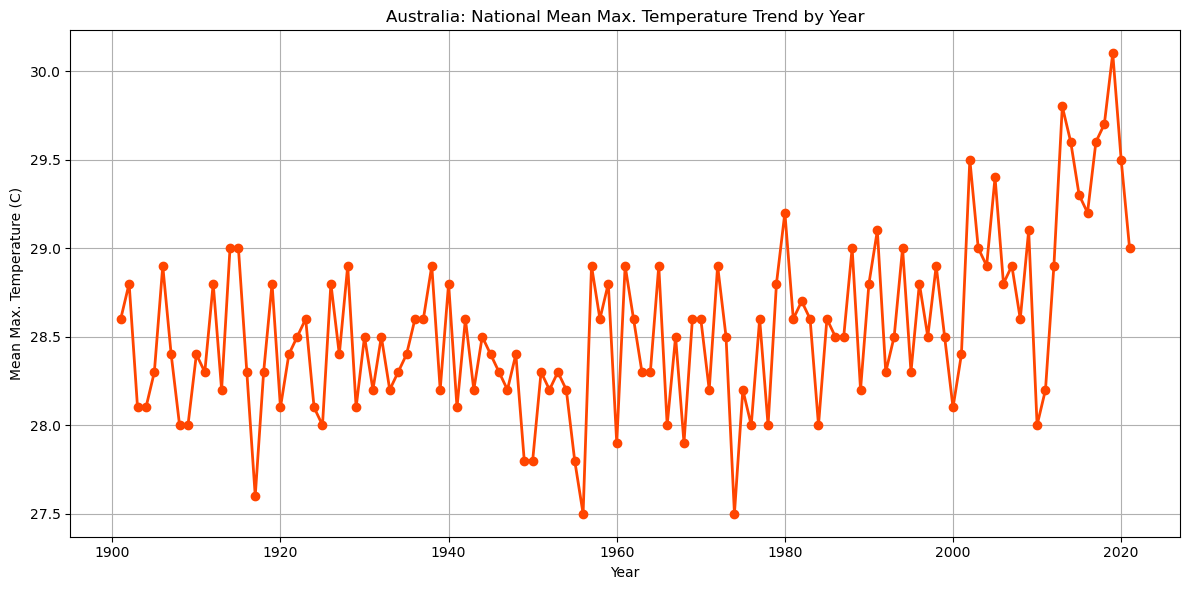

In [14]:
# Max. Mean Temperature Trend

plt.figure(figsize=(12, 6))
plt.plot(final_temp_df["Year"], final_temp_df["High_Mean_C"], marker="o", color="orangered", linewidth=2)
plt.title("Australia: National Mean Max. Temperature Trend by Year")
plt.xlabel("Year")
plt.ylabel("Mean Max. Temperature (C)")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "temp", "maximum_mean_temp_by_year.png"))
plt.show()

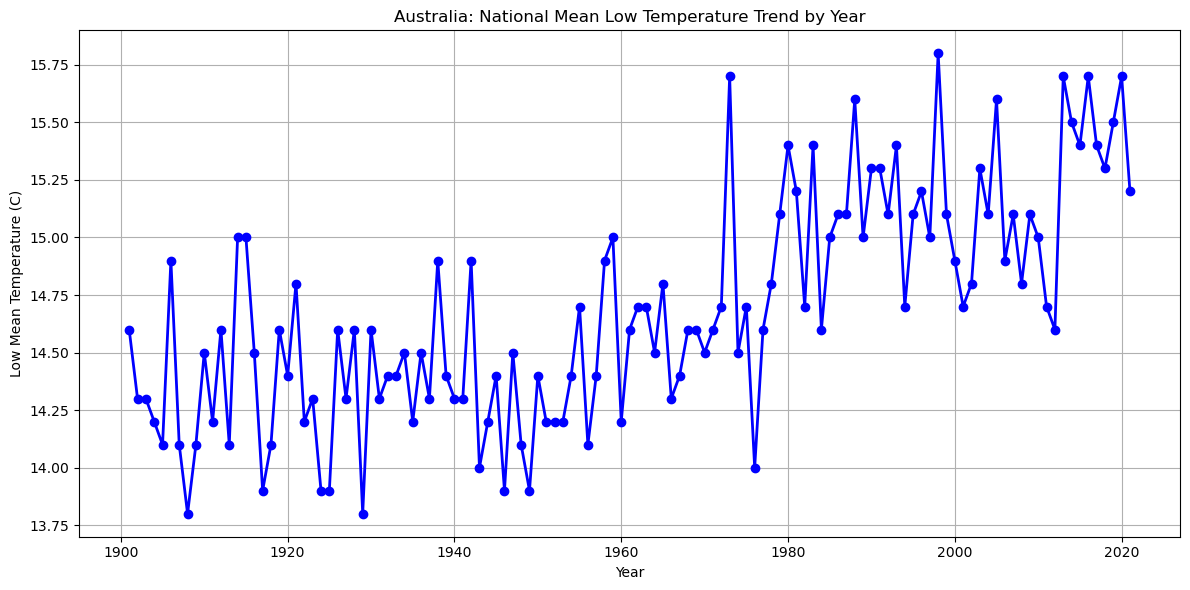

In [17]:
# Low Mean Temperature Trend

plt.figure(figsize=(12, 6))
plt.plot(final_temp_df["Year"], final_temp_df["Low_Mean_C"], marker="o", color="blue", linewidth=2)
plt.title("Australia: National Mean Low Temperature Trend by Year")
plt.xlabel("Year")
plt.ylabel("Low Mean Temperature (C)")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "temp", "low_mean_temp_by_year.png"))
plt.show()

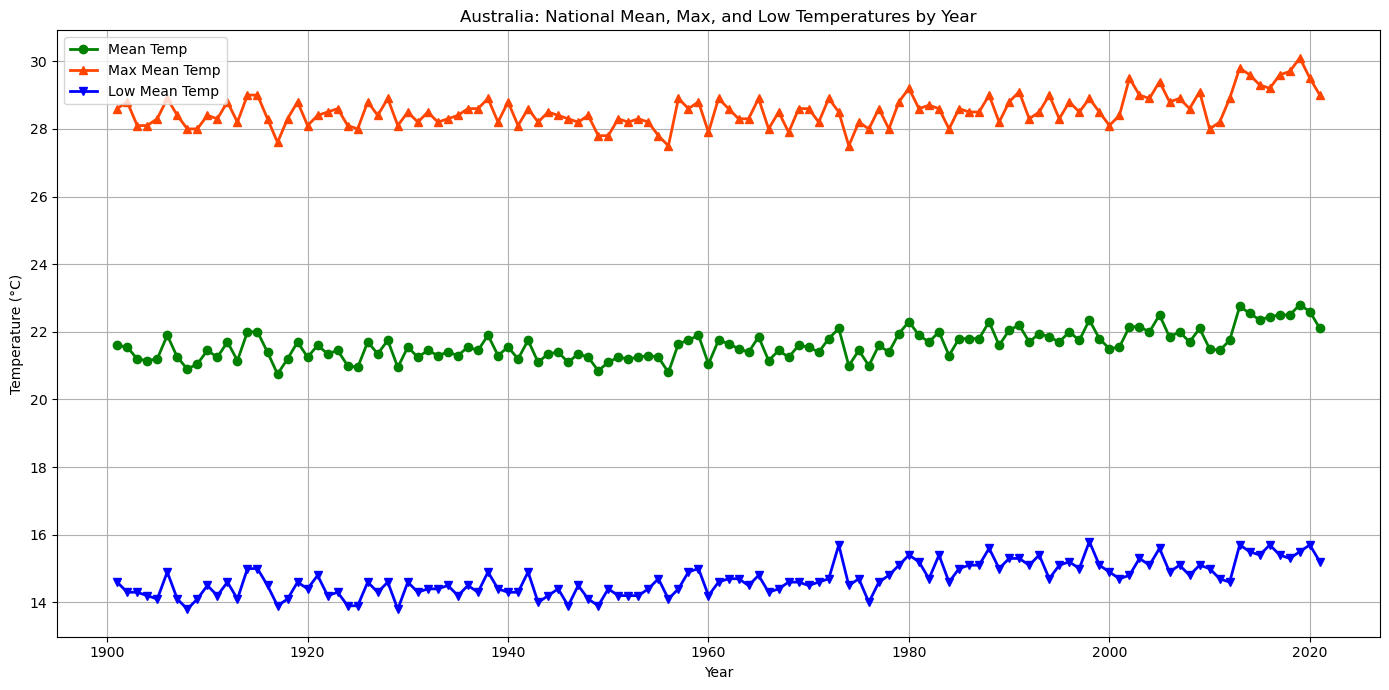

In [18]:
plt.figure(figsize=(14, 7))
plt.plot(final_temp_df["Year"], final_temp_df["Mean_Temperature"], marker="o", color="green", linewidth=2, label="Mean Temp")
plt.plot(final_temp_df["Year"], final_temp_df["High_Mean_C"], marker="^", color="orangered", linewidth=2, label="Max Mean Temp")
plt.plot(final_temp_df["Year"], final_temp_df["Low_Mean_C"], marker="v", color="blue", linewidth=2, label="Low Mean Temp")
plt.title("Australia: National Mean, Max, and Low Temperatures by Year")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "temp", "combined_mean_max_low_temp_by_year.png"))
plt.show()